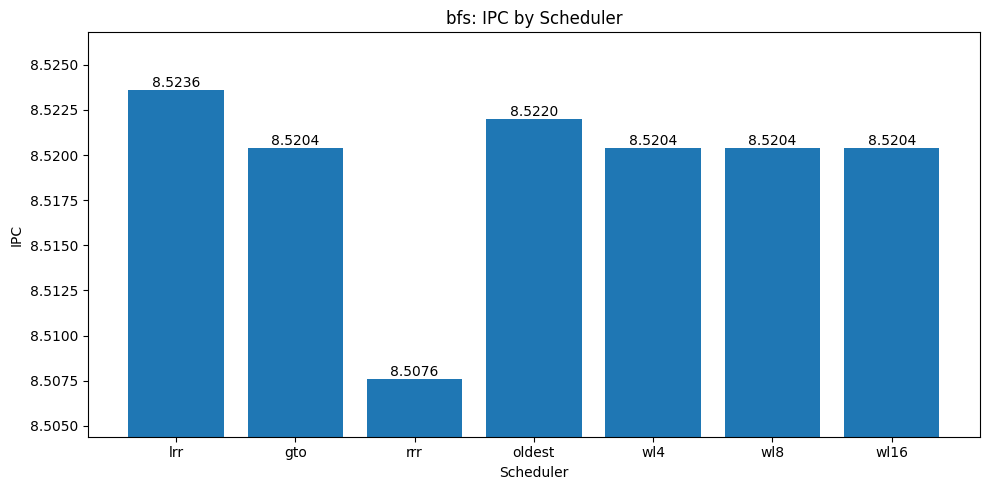

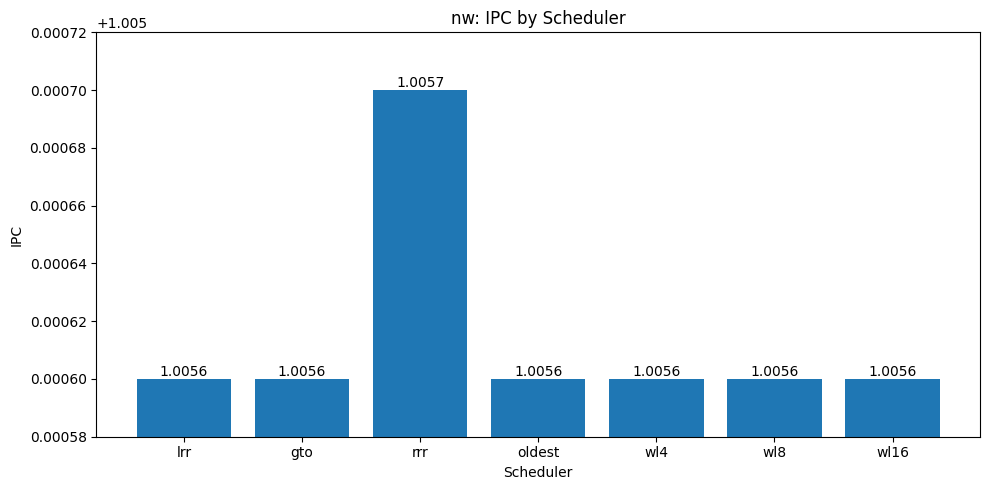

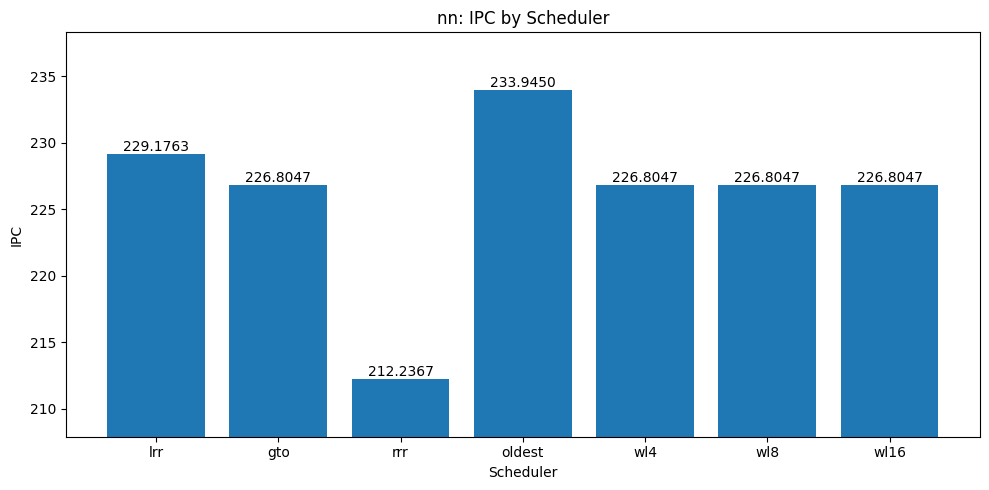

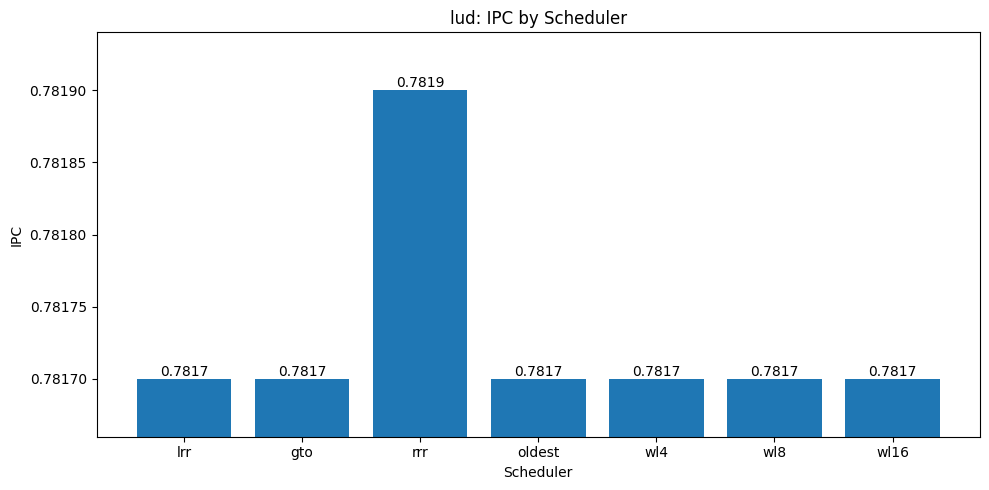

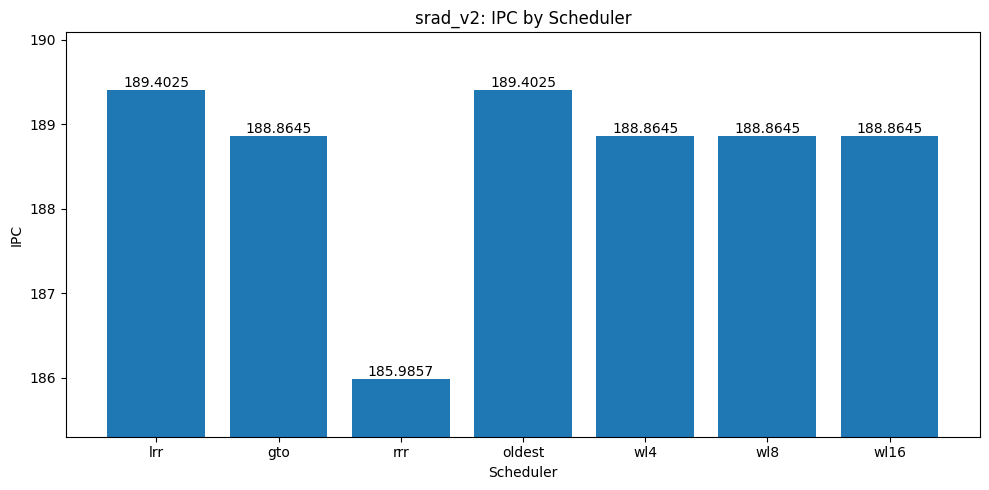

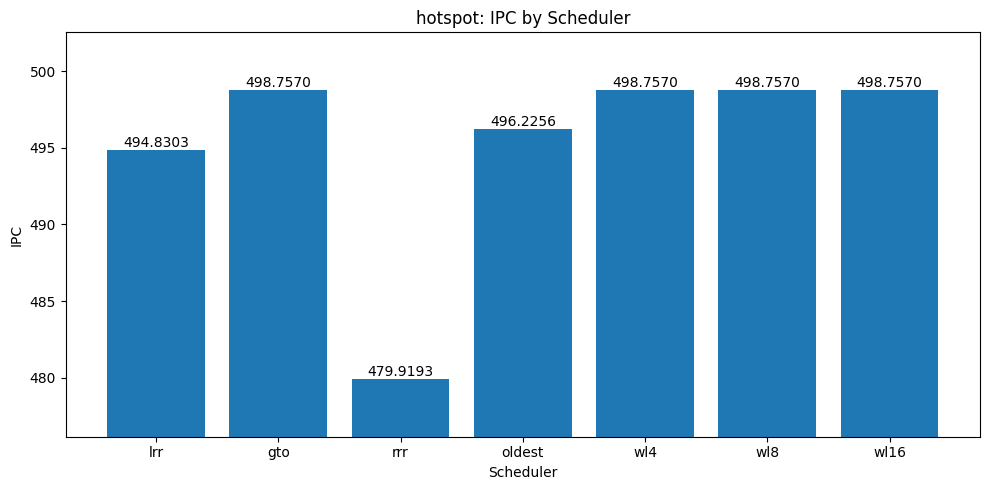

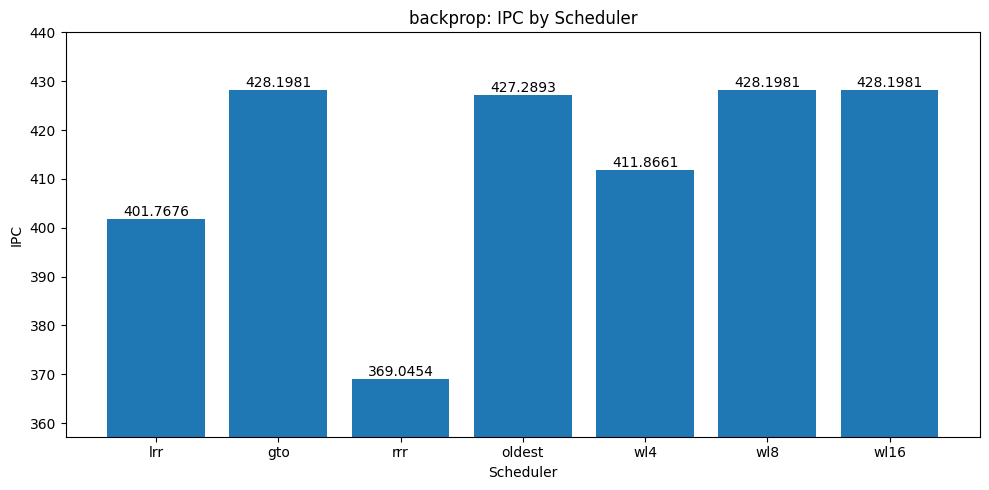

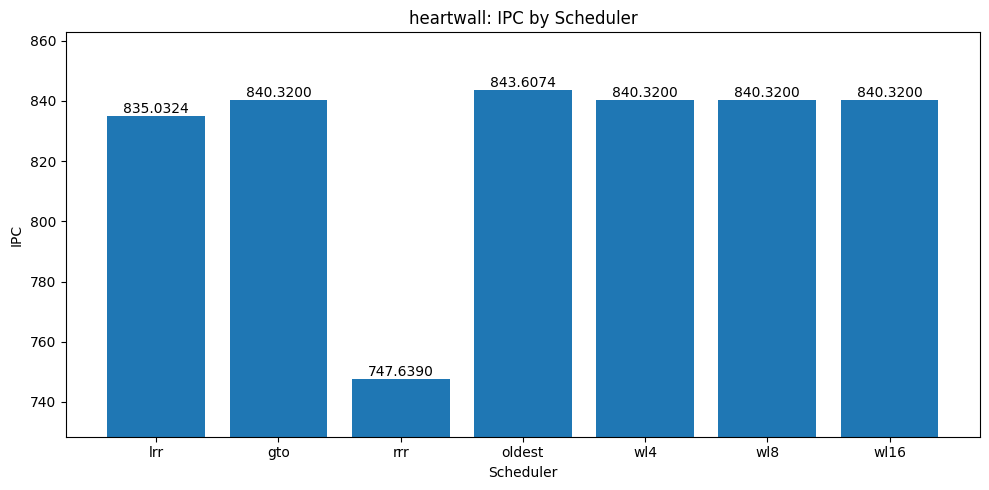

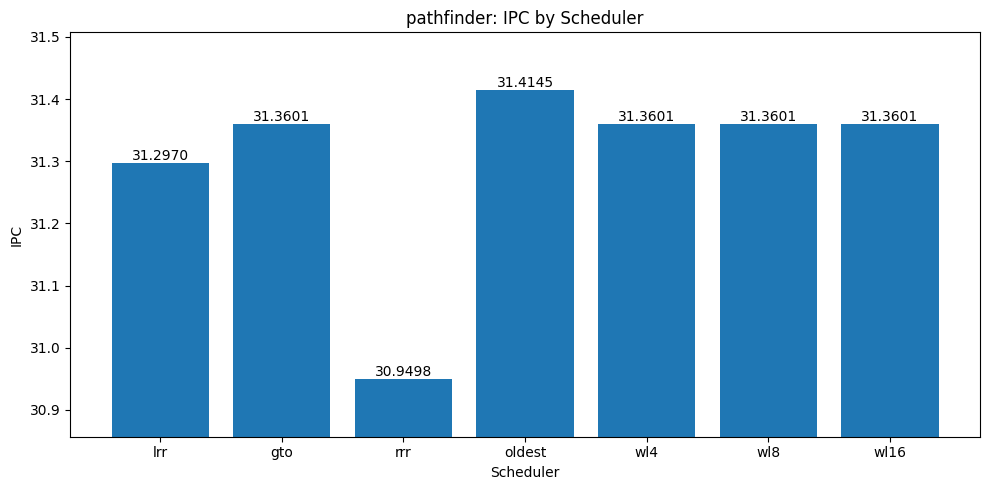

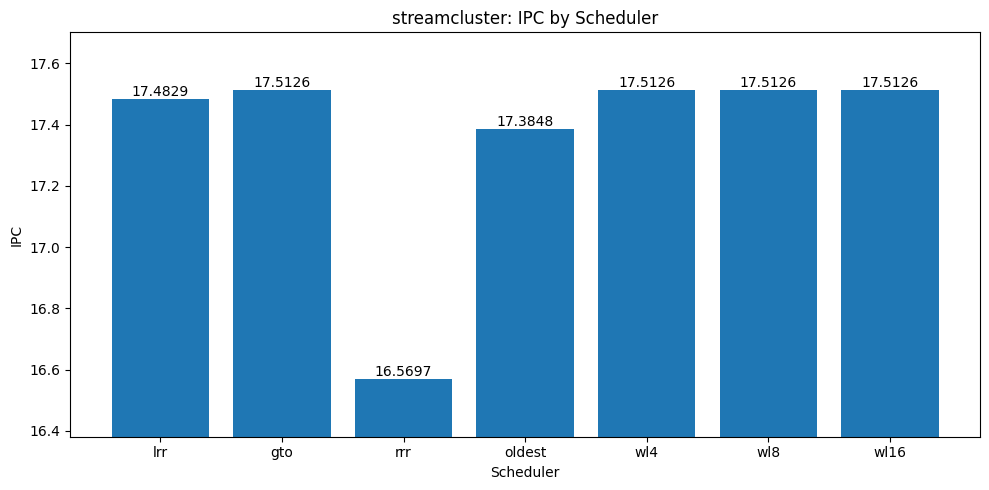

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV
df = pd.read_csv("../results/feasibility/results.csv")

scheduler_order = ["lrr", "gto", "rrr", "oldest", "wl4", "wl8", "wl16"]

workload_order = [
    "bfs",
    "nw",
    "nn",
    "lud",
    "srad_v2",
    "hotspot",
    "backprop",
    "heartwall",
    "pathfinder",
    "streamcluster",
]

for workload in workload_order:
    data = df[df["workload"] == workload].copy()

    # Keep schedulers in a clean, fixed order
    data["scheduler"] = pd.Categorical(
        data["scheduler"],
        categories=scheduler_order,
        ordered=True
    )
    data = data.sort_values("scheduler")

    fig, ax = plt.subplots(figsize=(10, 5))

    bars = ax.bar(data["scheduler"], data["ipc"])

    ax.set_title(f"{workload}: IPC by Scheduler")
    ax.set_xlabel("Scheduler")
    ax.set_ylabel("IPC")

    # Zoom in around the IPC range so small differences are visible
    ipc_min = data["ipc"].min()
    ipc_max = data["ipc"].max()
    ipc_range = ipc_max - ipc_min

    # If all values are almost identical, still give some visible padding
    if ipc_range == 0:
        padding = ipc_max * 0.01 if ipc_max != 0 else 0.01
    else:
        padding = ipc_range * 0.2

    ax.set_ylim(ipc_min - padding, ipc_max + padding)

    # Put exact IPC values above each bar
    for bar, value in zip(bars, data["ipc"]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{value:.4f}",
            ha="center",
            va="bottom"
        )

    plt.tight_layout()
    plt.show()